Phi* used = 250.000000
B* = 4500.000000
Candidate H* diagnostics:
  H*=3761.514455: C=10087.424027, required=671.066331, max_possible=858.644809, ratio=0.7815 -> valid
  H*=15381.342688: C=307.329553, required=491.536076, max_possible=1509.355191, ratio=0.3257 -> valid

Admissible endemic sets:
  H*=3761.514455 -> T*+V*=10087.424027, f*=1788.761528
  H*=15381.342688 -> T*+V*=307.329553, f*=241.465340

Saved figure: endemic.png (dpi=300)


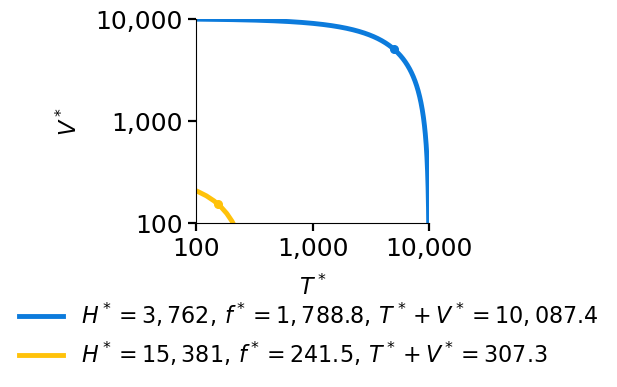

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

@dataclass(frozen=True)
class Params:
    a: float
    epsilon_T: float
    delta: float
    gamma_T: float
    gamma_B: float
    gamma_H: float
    kappa: float
    tau: float
    phi_B: float
    phi_H: float
    epsilon_B: float
    b: float
    k: float
    Phi_star: float


def compute_B_star(p: Params) -> float | None:
    den = p.epsilon_T * p.delta - p.gamma_T
    if den <= 0:
        return None
    return p.gamma_T * p.a / den


def solve_H_stars_from_df0(p: Params, B_star: float) -> list[float]:
    # phi_H H^2 + (phi_B B* + phi_H k - Phi*)H + phi_B B* k = 0
    A = p.phi_H
    Bq = p.phi_B * B_star + p.phi_H * p.k - p.Phi_star
    C = p.phi_B * B_star * p.k
    D = Bq * Bq - 4.0 * A * C

    if D < 0:
        return []

    sqrt_D = math.sqrt(D)
    r1 = (-Bq + sqrt_D) / (2.0 * A)
    r2 = (-Bq - sqrt_D) / (2.0 * A)
    return sorted([h for h in (r1, r2) if h > 0])


def compute_C_for_H(p: Params, B_star: float, H_star: float) -> float | None:
    if H_star <= 0:
        return None
    log_arg = (p.kappa * B_star) / (p.gamma_H * H_star)
    if log_arg <= 0:
        return None
    return ((p.a + B_star) / (p.delta * p.tau)) * (
        math.log(log_arg) - p.gamma_B * p.tau
    )


def db_balance_diagnostics(p: Params, B_star: float, H_star: float, C_val: float) -> dict:
    rhs_required = (
        p.delta * (B_star / (p.a + B_star)) * C_val
        + p.gamma_B * B_star
        + p.gamma_H * H_star
    )
    lhs_max = p.epsilon_B * (H_star / (p.k + H_star))
    ratio = rhs_required / lhs_max if lhs_max > 0 else math.inf
    q = ratio
    f_star = p.b * q / (1 - q) if 0 < q < 1 else math.nan
    feasible = rhs_required < lhs_max

    return {
        "rhs_required": rhs_required,
        "lhs_max": lhs_max,
        "ratio": ratio,
        "q": q,
        "f_star": f_star,
        "feasible": feasible,
    }


def plot_endemic_segments(
    p: Params,
    H_candidates: list[float] | None = None,
    save_path: str | None = "endemic_segments.png",
) -> None:
    B_color = (12 / 255, 123 / 255, 220 / 255)   # blue
    H_color = (255 / 255, 194 / 255, 10 / 255)   # yellow

    B_star = compute_B_star(p)
    if B_star is None:
        print("No interior endemic equilibrium: epsilon_T * delta <= gamma_T.")
        print(f"epsilon_T*delta = {p.epsilon_T * p.delta:.6f}, gamma_T = {p.gamma_T:.6f}")
        return

    if H_candidates is None:
        H_candidates = solve_H_stars_from_df0(p, B_star)

    if not H_candidates:
        print("No positive H* roots from df/dt=0.")
        return

    print(f"Phi* used = {p.Phi_star:.6f}")
    print(f"B* = {B_star:.6f}")
    print("Candidate H* diagnostics:")

    valid = []  # (H, C, f*)
    for H in H_candidates:
        C_val = compute_C_for_H(p, B_star, H)
        if C_val is None or C_val <= 0:
            print(f"  H*={H:.6f}: C(H*)={C_val} -> reject (C<=0 or invalid)")
            continue

        d = db_balance_diagnostics(p, B_star, H, C_val)
        status = "valid" if d["feasible"] else "reject (dB/dt infeasible)"
        print(
            f"  H*={H:.6f}: C={C_val:.6f}, required={d['rhs_required']:.6f}, "
            f"max_possible={d['lhs_max']:.6f}, ratio={d['ratio']:.4f} -> {status}"
        )

        if d["feasible"] and not math.isnan(d["f_star"]) and d["f_star"] > 0:
            valid.append((H, C_val, d["f_star"]))

    if not valid:
        print("No biologically valid endemic equilibrium set after all 5 equilibrium checks.")
        return

    print("\nAdmissible endemic sets:")
    for H, C_val, f_star in valid:
        print(f"  H*={H:.6f} -> T*+V*={C_val:.6f}, f*={f_star:.6f}")

    maxC = max(C for _, C, _ in valid)
    t_grid = np.linspace(1.0, maxC, 500)  # start at 1 to avoid log(0)

    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    line_handles = []
    line_labels = []

    for i, (H, C_val, f_star) in enumerate(valid):
        T = t_grid[t_grid <= C_val]
        V = C_val - T

        # keep only positive V for log scale
        mask = V > 0
        T = T[mask]
        V = V[mask]

        color = B_color if i % 2 == 0 else H_color

        ln, = ax.plot(
            T, V, color=color, linewidth=3.5,
            label=fr"$H^*={H:,.0f},\, f^*={f_star:,.1f},\, T^*+V^*={C_val:,.1f}$",
        )

        ax.scatter([0.5 * C_val], [0.5 * C_val], color=color, s=30, zorder=3)

        line_handles.append(ln)
        line_labels.append(ln.get_label())

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"$T^*$", color="black", fontsize=16, labelpad=10)
    ax.set_ylabel(r"$V^*$", color="black", fontsize=16, labelpad=10)
    ax.grid(False)

    ax.tick_params(axis="x", which="major", labelsize=18, width=1.6, length=6, colors="black")
    ax.tick_params(axis="y", which="major", labelsize=18, width=1.6, length=6, colors="black")

    ax.set_xlim(100, 10000)
    ax.set_ylim(100, 10000)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_yticks([100, 1000, 10000])
    ax.set_yticklabels(["100", "1,000", "10,000"])
    ax.set_xticks([100, 1000, 10000])
    ax.set_xticklabels(["100", "1,000", "10,000"])
    ax.minorticks_off()

    handles = line_handles
    labels = line_labels

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=1,
        fontsize=16,
        frameon=False,
        bbox_to_anchor=(0.5, -0.35),
    )

    plt.subplots_adjust(bottom=0.2, wspace=0.5)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"\nSaved figure: {save_path} (dpi=300)")

    plt.show()


# ---------------- USER PARAMETERS (before plot call) ----------------
params = Params(
    a=500,
    epsilon_T=1,
    delta=0.06,
    gamma_T=0.054,  # accepted
    gamma_B=0.003,
    gamma_H=0.03,   # accepted
    kappa=1/9,
    tau=12,
    phi_B=0.018,
    phi_H=0.007,
    epsilon_B=2000,
    b=500,
    k=5000,
    Phi_star=250,
)

H_star_candidates = None  # or e.g. [40000, 60000]
save_path = "endemic.png"

# ---------------- RUN PLOT ----------------
plot_endemic_segments(params, H_star_candidates, save_path=save_path)
